1: [10 pts] Download the labeled dataset (if you like, use a dummy email address for 
registration). There must be 8 data files, each representing a particular cyber-attack type, 
its day, and its collected packet capture (“PCAP”) data. 

Okay downloaded the GeneratedLabelledFlows.zip file.

2: [10 pts] Pick one of the data files, call it Dataset 1, and examine its features. Make sure it has more than one class value for its label. 

Going to use the Friday-WorkingHours DDos file for the data set.

In [1]:
#read in the file
import pandas as pd
file_path = r"C:\Users\jbosb\OneDrive\Desktop\Python_Work\Hopkins Studies\Applied_ML\TrafficLabelling\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
Dataset_1 = pd.read_csv(file_path)
print(Dataset_1.shape)
#print(Dataset_1.head())
#change max rows and columns to display so I can see all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print(Dataset_1.dtypes)

#definitely need to strip whitespace from column names
Dataset_1.columns = Dataset_1.columns.str.strip()
print(Dataset_1['Label'].value_counts())

(225745, 85)
Flow ID                             str
 Source IP                          str
 Source Port                      int64
 Destination IP                     str
 Destination Port                 int64
 Protocol                         int64
 Timestamp                          str
 Flow Duration                    int64
 Total Fwd Packets                int64
 Total Backward Packets           int64
Total Length of Fwd Packets       int64
 Total Length of Bwd Packets      int64
 Fwd Packet Length Max            int64
 Fwd Packet Length Min            int64
 Fwd Packet Length Mean         float64
 Fwd Packet Length Std          float64
Bwd Packet Length Max             int64
 Bwd Packet Length Min            int64
 Bwd Packet Length Mean         float64
 Bwd Packet Length Std          float64
Flow Bytes/s                    float64
 Flow Packets/s                 float64
 Flow IAT Mean                  float64
 Flow IAT Std                   float64
 Flow IAT Max              

3: [10 pts] For your Dataset 1, pick a machine learning methodology and justify your choice. 

Going to check unique values of dataset to see how sparse this is.

I'm going to start off using a random forest as it can handle the higher dimensionality of the data well and has built in feature importance. We have a wide range of feature scales and random forest is unaffected and does not require scaling features initially. 

In [2]:
#print out column names to make it easier to drop later
print(Dataset_1.columns)

Index(['Flow ID', 'Source IP', 'Source Port', 'Destination IP',
       'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration',
       'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
  

In [3]:
#start setting up random forest classifier
#first need to remove some features such as timestame and FlowID since those are identifiers and can lead to overfitting
Dataset_1 = Dataset_1.drop(['Flow ID', 'Timestamp'], axis=1) #may revist this later but for now these two features
#remove the columns that have only one unique value since they don't help with classification
for col in Dataset_1.columns:
    if Dataset_1[col].nunique() == 1:
        print(f"Column: {col} has only one unique value and will be dropped.")
        Dataset_1 = Dataset_1.drop(col, axis=1)
#check the shape again after dropping columns
print(Dataset_1.shape)
#dropped total of 12 columns, 73 features left
#deal with missing values in Flow Bytes/s column, since it's a numeric column I will fill the missing values with the median
import numpy as np
#in Flow Bytes/s there are some NaN values and infinity values
#Flow Packets/s there are some infinity values, need to consider how repalce those
#first replace infinity value with large static value, then fill NaN with median, will try that for now and revist later
Dataset_1['Flow Bytes/s'] = Dataset_1['Flow Bytes/s'].replace([np.inf, -np.inf], 9999999999)
Dataset_1['Flow Packets/s'] = Dataset_1['Flow Packets/s'].replace([np.inf, -np.inf], 9999999999)
#now fill NaN with median
Dataset_1['Flow Bytes/s'] = Dataset_1['Flow Bytes/s'].fillna(Dataset_1['Flow Bytes/s'].median())


#check for missing values again to confirm
print(Dataset_1.isnull().sum())

Column: Bwd PSH Flags has only one unique value and will be dropped.
Column: Fwd URG Flags has only one unique value and will be dropped.
Column: Bwd URG Flags has only one unique value and will be dropped.
Column: CWE Flag Count has only one unique value and will be dropped.
Column: Fwd Avg Bytes/Bulk has only one unique value and will be dropped.
Column: Fwd Avg Packets/Bulk has only one unique value and will be dropped.
Column: Fwd Avg Bulk Rate has only one unique value and will be dropped.
Column: Bwd Avg Bytes/Bulk has only one unique value and will be dropped.
Column: Bwd Avg Packets/Bulk has only one unique value and will be dropped.
Column: Bwd Avg Bulk Rate has only one unique value and will be dropped.
(225745, 73)
Source IP                      0
Source Port                    0
Destination IP                 0
Destination Port               0
Protocol                       0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0


4. [10 pts] Process the class feature/category as binary classes for supervised learning, 
assign BENIGN to value 0 and the rest to value 1. Check its balance for the Dataset 1.

Balance here is 128027/97718 not great but not horrible.

In [4]:
#need to encode the label column as it is a categorical, no need to one-hot, just convert to binary
Dataset_1['Label'] = Dataset_1['Label'].map({'BENIGN': 0, 'DDoS': 1})
print(Dataset_1['Label'].value_counts()) #all good, bening = 0, DDoS = 1
#imbalanced dataset, will address later 


Label
1    128027
0     97718
Name: count, dtype: int64


5. [10 pts] Explore Dataset 1 features with respect to the class. (Hint: features Source Port 
and Destination Port are very useful; research and find out important networking port 
numbers and one-hot-encode them. Unimportant port numbers or source port numbers can 
be assigned to a feature called 'other ports'.) 

Need to read on Source Port and Destination Port. For source port have 50697 unique values and for destination port 23950 unique values.

Common identifiers for DDoS attack, massive spike of incomming traffic, excessive requests from similar IP ranges, or a single IP

Check HTTP Port 80, and HTTPS port 443
Also check ports 52 and 53 for DNS
LDAP port 389

List of ports of interest: 0, 80, 443, 52, 53, 389

ICMP would use protocol 1, need to one hot encode that since it's only three values anyway. 




In [5]:
#print out column names and number of unique values for exploration
for col in Dataset_1.columns:
    print(f"Column: {col}: {Dataset_1[col].nunique()}")

Column: Source IP: 2067
Column: Source Port: 50697
Column: Destination IP: 2554
Column: Destination Port: 23950
Column: Protocol: 3
Column: Flow Duration: 187752
Column: Total Fwd Packets: 297
Column: Total Backward Packets: 367
Column: Total Length of Fwd Packets: 3831
Column: Total Length of Bwd Packets: 6760
Column: Fwd Packet Length Max: 1891
Column: Fwd Packet Length Min: 151
Column: Fwd Packet Length Mean: 7401
Column: Fwd Packet Length Std: 9555
Column: Bwd Packet Length Max: 1945
Column: Bwd Packet Length Min: 343
Column: Bwd Packet Length Mean: 8655
Column: Bwd Packet Length Std: 9650
Column: Flow Bytes/s: 202293
Column: Flow Packets/s: 194094
Column: Flow IAT Mean: 193666
Column: Flow IAT Std: 159622
Column: Flow IAT Max: 139745
Column: Flow IAT Min: 11093
Column: Fwd IAT Total: 78049
Column: Fwd IAT Mean: 95095
Column: Fwd IAT Std: 91184
Column: Fwd IAT Max: 77978
Column: Fwd IAT Min: 8820
Column: Bwd IAT Total: 101942
Column: Bwd IAT Mean: 117311
Column: Bwd IAT Std: 113859

In [6]:
#need to one-hot encode a few ports and all others to "other port" category, will be applied to both source and destination
#ports of interest, 0, 80, 443, 52, 53, 389
#one hot encode protocol

from sklearn.preprocessing import OneHotEncoder
ports_of_interest = [0, 80, 443, 52, 53, 389]
Dataset_1['Source Port'] = Dataset_1['Source Port'].apply(lambda x: x if x in ports_of_interest else 'other port')
Dataset_1['Destination Port'] = Dataset_1['Destination Port'].apply(lambda x: x if x in ports_of_interest else 'other port')
#before we go any further lets define x and y for the model
X = Dataset_1.drop('Label', axis=1) #drop the label column to get the features
y = Dataset_1['Label'] #now we can one-hot encode the source and destination ports and protocol
#check shape of x and y
print(X.shape)
print(y.shape)
#one-hot encode the source and destination ports and protocol
#columns that need to be encoded Source Port, Destination Port, Protocol definitely
#columns the flag count columns do not need to be encoded since they are binary
encoder = OneHotEncoder(drop='first', sparse_output=False) #drop first to avoid multicollinearity, sparse=False to get a dense array
cat_columns = ['Source Port', 'Destination Port', 'Protocol', 'Down/Up Ratio', 'min_seg_size_forward'] 
#will start with these columns and see how it goes, may need to add more later or just drop some of these
X_encoded = pd.get_dummies(X, columns=cat_columns, drop_first=True) #drop_first to avoid multicollinearity
print(X_encoded.shape)


(225745, 72)
(225745,)
(225745, 93)


6. [10 pts] Display some histograms and anything you deem fit to pick independent Dataset 1 
features. (Hint: source/destination bytes, packets, ports and the duration features.) 

I started with a correlation matrix to see if there are any direct correlations and then investigated the suggested features. This histograms and box plots show distinct signatures to the flow of information for an attack differentiating it from benign samples making it very easy to distinguish a DDoS attack.

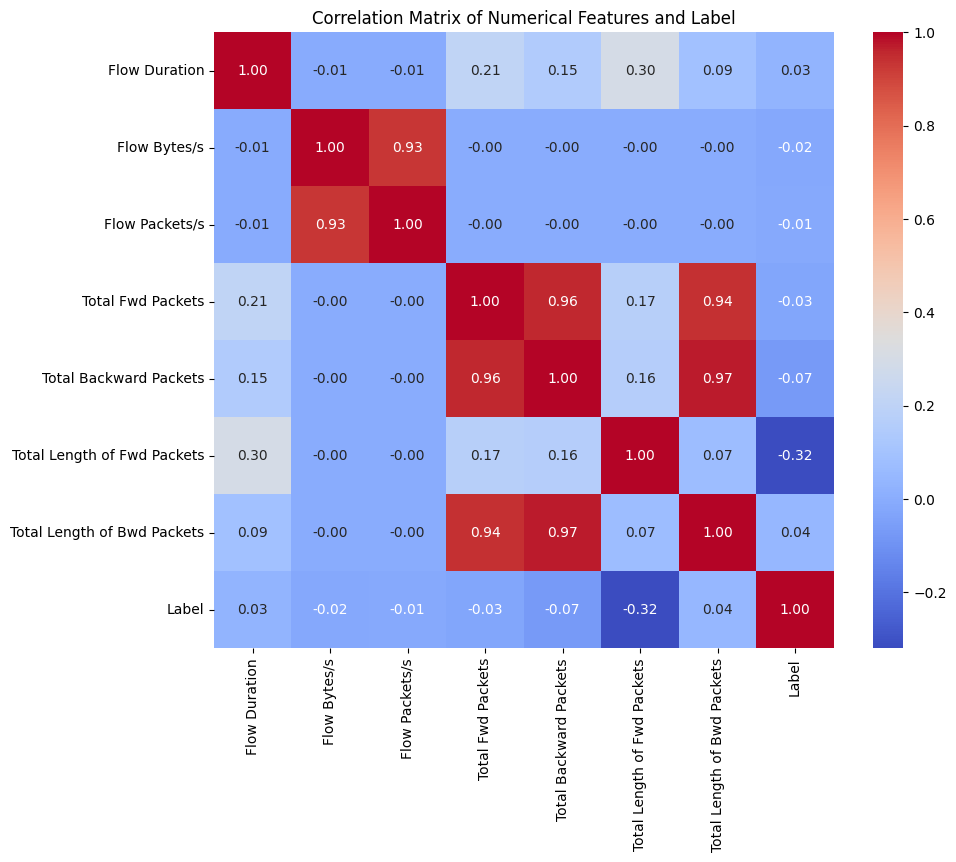

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
#check for correlation between features and label
#since we have a lot of features, we will just look at the top 20 most correlated features with the label
#need to grab the numerical features for correlation
#check the correlation with source/desination bytes, packets, ports and duration
numerical_features = ['Flow Duration', 'Flow Bytes/s', 'Flow Packets/s', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets',
                       'Total Length of Bwd Packets']

#plot heatmap of correlation between numerical features and label
correlation_matrix = Dataset_1[numerical_features + ['Label']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features and Label')
plt.show()


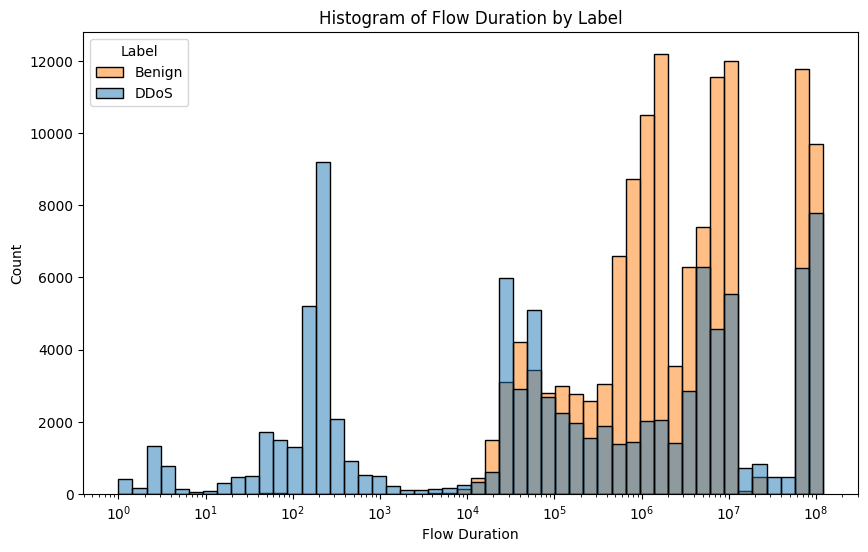

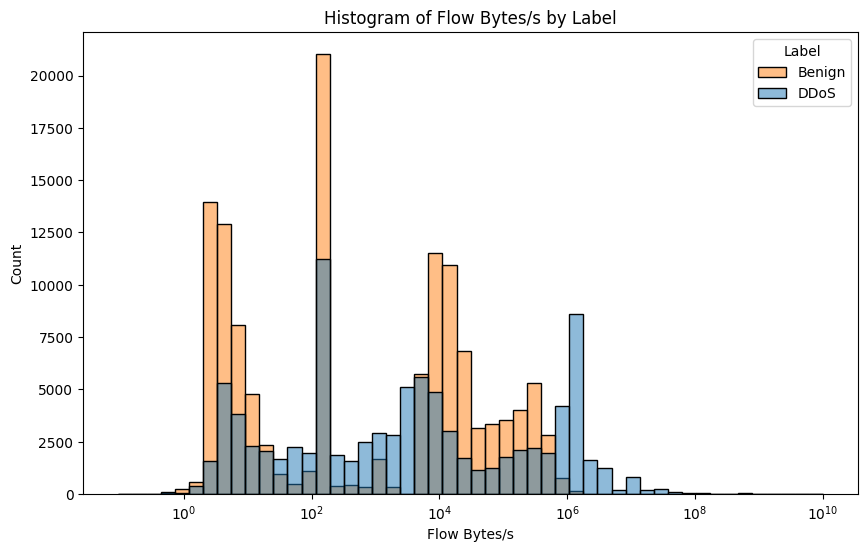

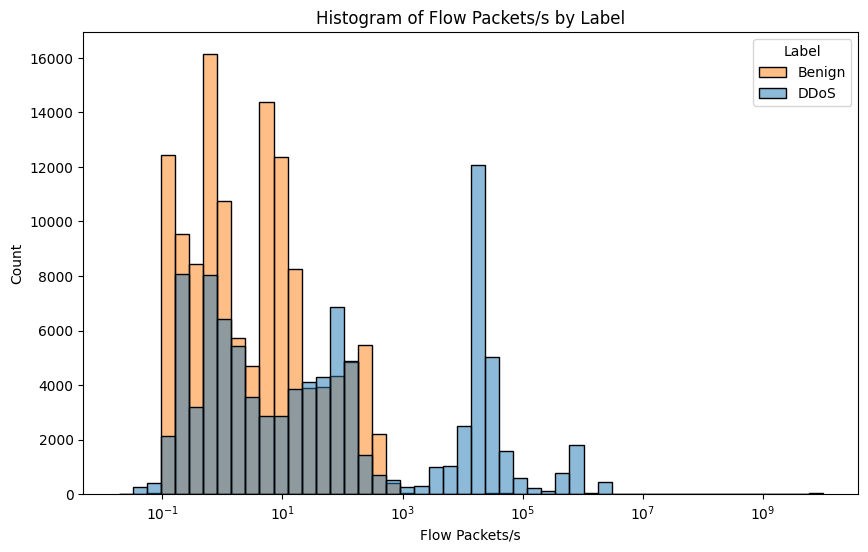

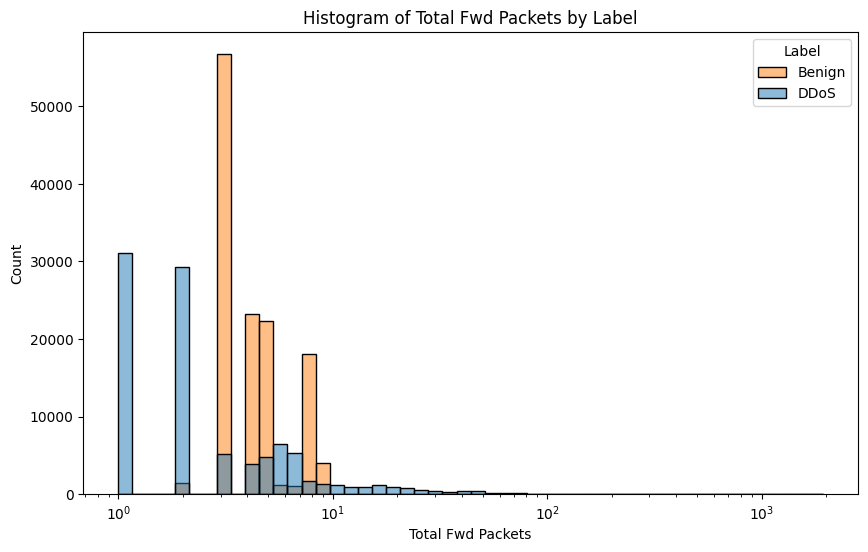

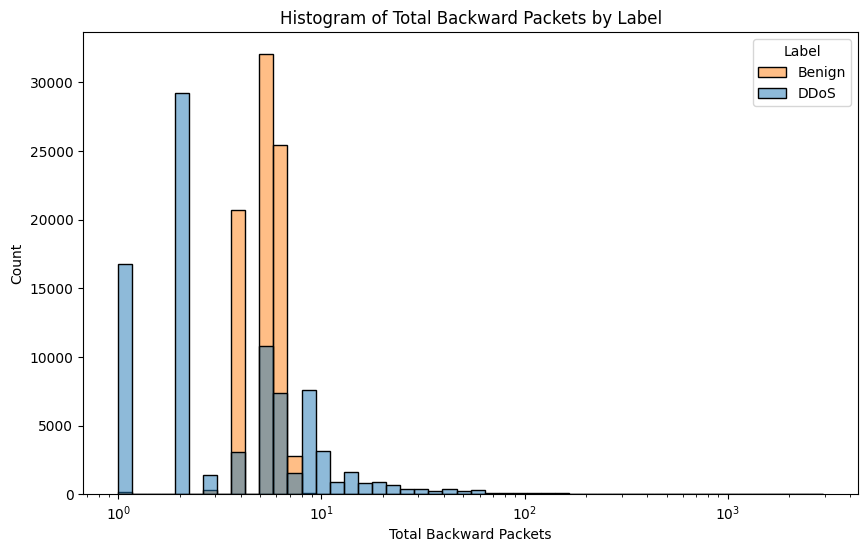

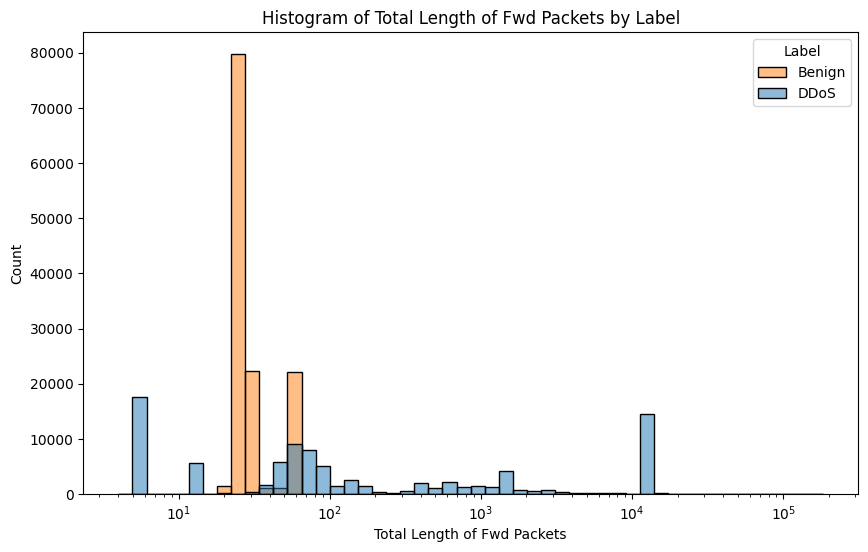

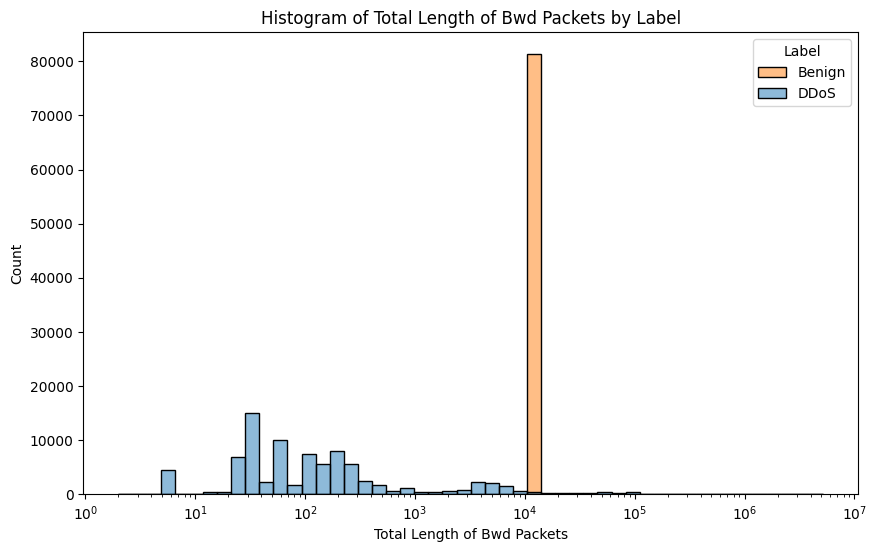

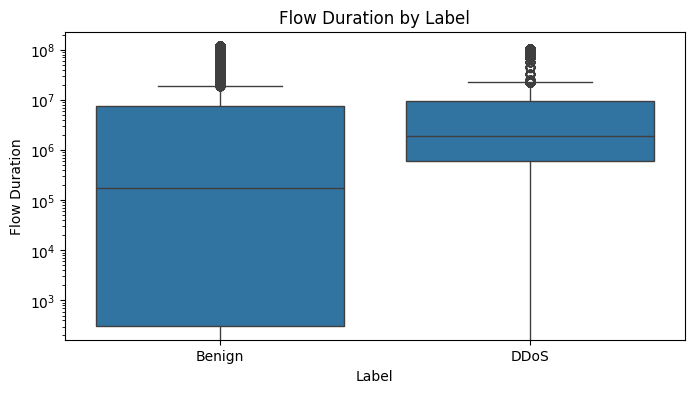

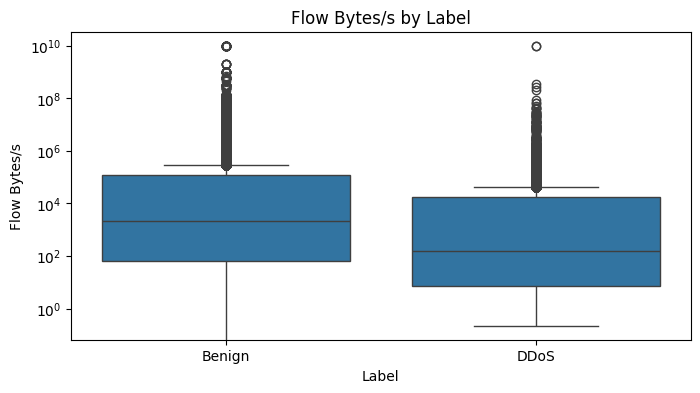

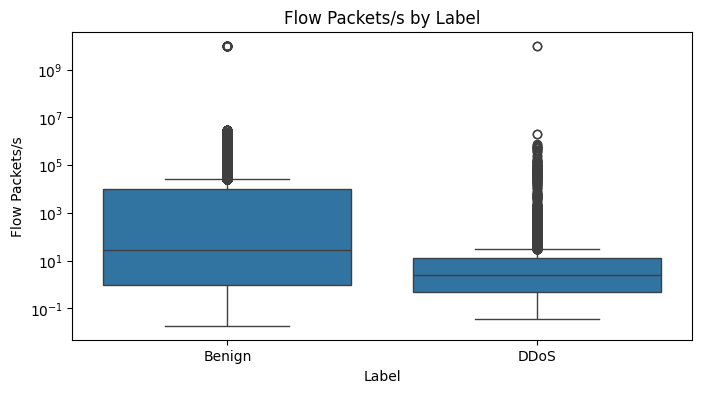

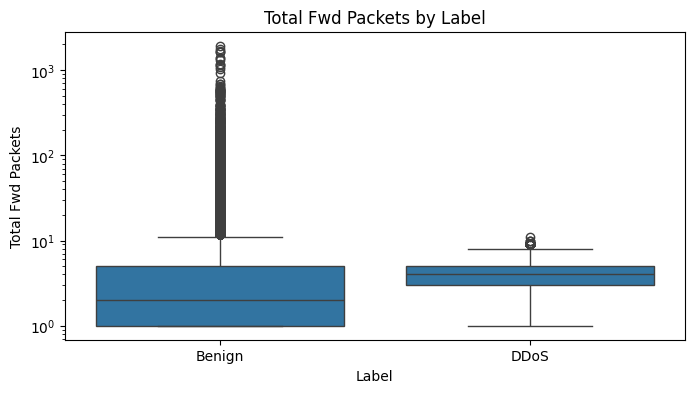

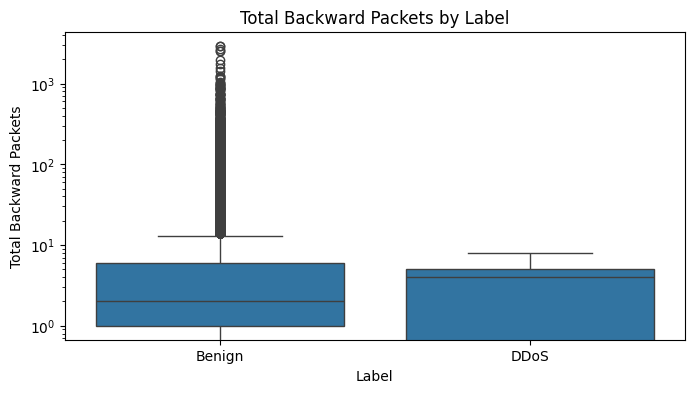

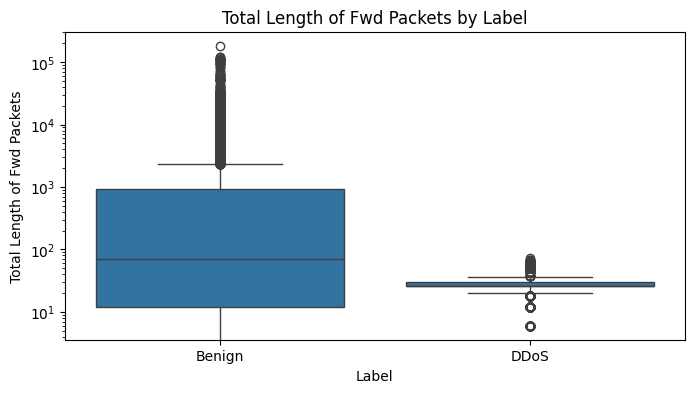

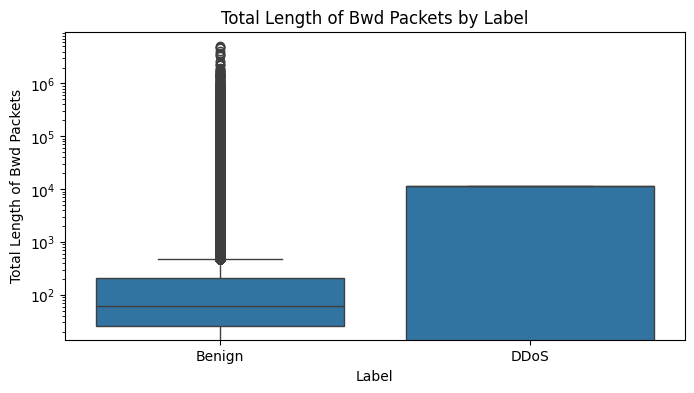

In [8]:
#plot histograms of those numerical features and see if there are any clusters that standout
#need to adjust the scale of the features since some of them have very large values, will use log scale for the x-axis
for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=Dataset_1, x=feature, hue='Label', bins=50, log_scale=True)
    plt.title(f'Histogram of {feature} by Label')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend(title='Label', labels=['Benign', 'DDoS'])
    plt.show()

for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=Dataset_1, x='Label', y=feature)
    plt.yscale('log')
    plt.title(f'{feature} by Label')
    plt.xticks([0, 1], ['Benign', 'DDoS'])
    plt.show()

7. [10 pts] Attempt a few classifier models and report their 10-fold CV performances.

Random Forest Mean F1 Score: 0.9999 ± 0.0000
Random Forest Mean Accuracy: 0.9999 ± 0.0000

Logistic Regression Mean F1 Score: 0.9994 ± 0.0001
Logistic Regression Mean Accuracy: 0.9994 ± 0.0001

LightGBM Mean F1 Score: 0.9999 ± 0.0001
LightGBM Mean Accuracy: 0.9999 ± 0.0001

This data looks very separable even with a logistic regression

In [9]:
#setup for a few models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold


def evaluate_classifier(model, X, y):
    f1_scores = []
    accuracy_scores = []
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        f1_scores.append(f1_score(y_test, y_pred))
        accuracy_scores.append(accuracy_score(y_test, y_pred))
    return f1_scores, accuracy_scores

In [10]:
#for random forest will need to convert IP addresses to integer values
import ipaddress
X_encoded['Source IP'] = X_encoded['Source IP'].apply(lambda x: int(ipaddress.IPv4Address(x)))
X_encoded['Destination IP'] = X_encoded['Destination IP'].apply(lambda x: int(ipaddress.IPv4Address(x)))
#drop the original str columns from X_encoded
#IP addresses have been converted but may be overly predictive, will remove for this model since it may lead to overfitting and not representative of real world data
X_encoded = X_encoded.drop(['Source IP', 'Destination IP', 'Destination Port_80'], axis=1) #had to remove port 80, that was too powerful a predictor for DDoS

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42, class_weight='balanced') #class weight balanced to address the imbalanced dataset
rf_f1_scores, rf_accuracies = evaluate_classifier(rf, X_encoded, y)
print(f"Random Forest F1 Scores: {rf_f1_scores}")
print(f"Random Forest Mean F1 Score: {np.mean(rf_f1_scores):.4f} ± {np.std(rf_f1_scores):.4f}")
print(f"Random Forest Accuracies: {rf_accuracies}")
print(f"Random Forest Mean Accuracy: {np.mean(rf_accuracies):.4f} ± {np.std(rf_accuracies):.4f}")

#check feature importance for random forest
feature_importances = rf.feature_importances_
feature_names = X_encoded.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df.head(20))




Random Forest F1 Scores: [0.9998437622060776, 0.9998828353837141, 0.9999218872051242, 0.999882826231301, 0.9998828353837141, 0.99984375, 0.9999609420771003, 0.9999218811030388, 0.9999609451279047, 0.9999609451279047]
Random Forest Mean F1 Score: 0.9999 ± 0.0000
Random Forest Accuracies: [0.9998228128460687, 0.9998671096345515, 0.9999114064230343, 0.9998671096345515, 0.9998671096345515, 0.9998228049968991, 0.9999557012492247, 0.9999114024984496, 0.9999557012492247, 0.9999557012492247]
Random Forest Mean Accuracy: 0.9999 ± 0.0000
                        Feature  Importance
5         Fwd Packet Length Max    0.091470
47         Avg Fwd Segment Size    0.084648
7        Fwd Packet Length Mean    0.079501
51            Subflow Fwd Bytes    0.057757
54       Init_Win_bytes_forward    0.046305
22                  Fwd IAT Max    0.044785
3   Total Length of Fwd Packets    0.044144
56             act_data_pkt_fwd    0.040978
48         Avg Bwd Segment Size    0.038443
21                  Fwd IA

Need to run a sanity check here and get a confusion matrix. Even with the removal of the Port_80 it's still almost perfect at classification. 

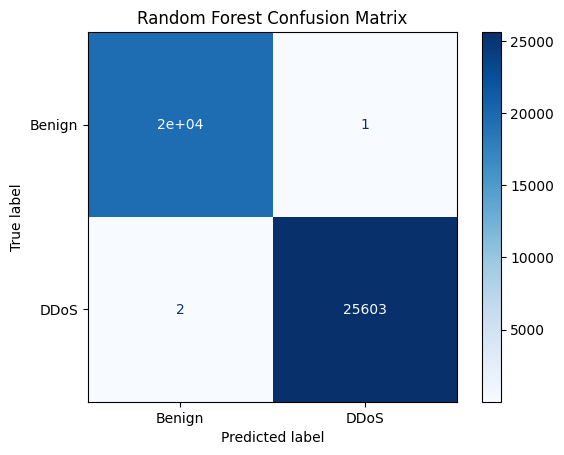

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     19544
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149



In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Fit on full data for visualization
rf_full = RandomForestClassifier(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y)
rf_full.fit(X_train, y_train)
y_pred = rf_full.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'DDoS'])
disp.plot(cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Benign', 'DDoS']))

In [12]:
#logistic regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
#need to scale X_encoded for logristic regression
scaler = StandardScaler()
X_encoded_scaled = scaler.fit_transform(X_encoded)
X_encoded_scaled = pd.DataFrame(X_encoded_scaled, columns=X_encoded.columns) #convert back to dataframe for consistency
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_f1, lr_acc = evaluate_classifier(lr, X_encoded_scaled, y)
print(f"Logistic Regression F1 Scores: {lr_f1}")
print(f"Logistic Regression Mean F1 Score: {np.mean(lr_f1):.4f} ± {np.std(lr_f1):.4f}")
print(f"Logistic Regression Accuracies: {lr_acc}")
print(f"Logistic Regression Mean Accuracy: {np.mean(lr_acc):.4f} ± {np.std(lr_acc):.4f}")

Logistic Regression F1 Scores: [0.9994530395374277, 0.9993750488243106, 0.9995703292840123, 0.999375, 0.99953125, 0.9993358596710552, 0.9994141311565051, 0.9994139022388935, 0.999453125, 0.9995313964386129]
Logistic Regression Mean F1 Score: 0.9994 ± 0.0001
Logistic Regression Accuracies: [0.9993798449612403, 0.9992912513842747, 0.9995127353266888, 0.9992912513842747, 0.999468438538206, 0.9992469212368211, 0.9993355187383716, 0.9993355187383716, 0.9993798174891468, 0.9994684149906973]
Logistic Regression Mean Accuracy: 0.9994 ± 0.0001


In [13]:
#lightGBM
import lightgbm as lgb
X_encoded_scaled.columns = X_encoded.columns.str.strip().str.replace(' ', '_') #strip whitespace and replace spaces with underscores for lightGBM
lgbm = lgb.LGBMClassifier(random_state=42)
lgbm_f1, lgbm_acc = evaluate_classifier(lgbm, X_encoded_scaled, y)
print(f"LightGBM F1 Scores: {lgbm_f1}")
print(f"LightGBM Mean F1 Score: {np.mean(lgbm_f1):.4f} ± {np.std(lgbm_f1):.4f}")
print(f"LightGBM Accuracies: {lgbm_acc}")
print(f"LightGBM Mean Accuracy: {np.mean(lgbm_acc):.4f} ± {np.std(lgbm_acc):.4f}")

[LightGBM] [Info] Number of positive: 115224, number of negative: 87946
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012376 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14026
[LightGBM] [Info] Number of data points in the train set: 203170, number of used features: 87
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567131 -> initscore=0.270155
[LightGBM] [Info] Start training from score 0.270155
[LightGBM] [Info] Number of positive: 115224, number of negative: 87946
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012425 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14038
[LightGBM] [Info] Number of data points in the train set: 203170, number of used features: 87
[LightGBM] [In

Question 8: [10 pts] Convert your code to be used for the remaining 7 datasets, i.e., Datasets 2-8. 

In [14]:

#adding in file paths for other datasets
file_path2 = r"C:\Users\jbosb\OneDrive\Desktop\Python_Work\Hopkins Studies\Applied_ML\TrafficLabelling\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv"
file_path3 = r"C:\Users\jbosb\OneDrive\Desktop\Python_Work\Hopkins Studies\Applied_ML\TrafficLabelling\Friday-WorkingHours-Morning.pcap_ISCX.csv"
file_path4 = r"C:\Users\jbosb\OneDrive\Desktop\Python_Work\Hopkins Studies\Applied_ML\TrafficLabelling\Monday-WorkingHours.pcap_ISCX.csv"
file_path5 = r"C:\Users\jbosb\OneDrive\Desktop\Python_Work\Hopkins Studies\Applied_ML\TrafficLabelling\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv"
file_path6 = r'C:\Users\jbosb\OneDrive\Desktop\Python_Work\Hopkins Studies\Applied_ML\TrafficLabelling\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
file_path7 = r"C:\Users\jbosb\OneDrive\Desktop\Python_Work\Hopkins Studies\Applied_ML\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv"
file_path8 = r"C:\Users\jbosb\OneDrive\Desktop\Python_Work\Hopkins Studies\Applied_ML\TrafficLabelling\Wednesday-workingHours.pcap_ISCX.csv"

from sklearn.preprocessing import LabelEncoder




Read in the other files and the Monday working hours file called Dataset_4 has only one class. The will have to adjust for unsupervised learning using k-means with the random forest. Also need to adjust encoding for Labels to handle more than one type of attack.

In addition to this there is a large number of data points in Dataset 6 which are unlabled. My initial thought is to drop the rows and withhold them from training.



In [15]:
#basic workflow for new pipeline of other datasets

#go back through preprocessing replace NaN with median value
#replace infinity with large static value
#encode the ports of interest,protocol, and categorical columns 
#drop columns, Flow ID, Timestamp, Source IP, Destination IP






In [16]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.base import clone
import pandas as pd
import numpy as np

#constants for preprocessing, ports, categorical columns, columns to drop, redfining these for the pipeline
ports_of_interest = [0, 80, 443, 52, 53, 389]
cat_columns_2       = ['Source Port', 'Destination Port', 'Protocol','Down/Up Ratio', 'min_seg_size_forward'] 
drop_columns_2     = ['Flow ID', 'Timestamp', 'Source IP', 'Destination IP']
INF_CAP_QUANTILE  = 0.99

#need to revmove warnings for now, just taking up too much space in the report
import warnings
with warnings.catch_warnings(): #supresses some warning to make output cleaner
    warnings.simplefilter("ignore", UserWarning)
    warnings.simplefilter("ignore", UndefinedMetricWarning)

#to handle different encoding in data set, trying some common ones
def load_raw(fp: str) -> pd.DataFrame: #tried a few encodings I could find to handle the datasets and seems to work
    for enc in ('utf-8', 'latin1', 'iso-8859-1', 'cp1252'):
        try:
            df = pd.read_csv(fp, encoding=enc, low_memory=False) #added low_memory for Dataset6 which has a problem
            df.columns = df.columns.str.strip()
            print(f"  [load] {enc}  shape={df.shape}")
            return df
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Could not read: {fp}")

#deal with numerical entrys, fill NaN with median and replace infinity with large value
def clean_numerics(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.select_dtypes(include=[np.number]).columns:
        finite = df[col].replace([np.inf, -np.inf], np.nan)
        cap    = finite.quantile(INF_CAP_QUANTILE)
        df[col] = finite.clip(upper=cap).fillna(finite.median())
    return df

def bucket_ports(df: pd.DataFrame) -> pd.DataFrame:
    # Replace uncommon port numbers with 'other port' string before encoding.
    for col in ('Source Port', 'Destination Port'):
        if col in df.columns:
            df[col] = df[col].apply(lambda x: x if x in ports_of_interest else 'other port').astype(str)  # ensure categorical dtype for later encoding
    return df

def encode_labels(df: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    #Encoding the label column to determine supervised vs unsupervised
    raw_labels = df['Label'].astype(str).str.strip()
    n_classes  = raw_labels.nunique()
    print(f"  [label] {n_classes} unique class(es): {raw_labels.unique().tolist()}")

    if n_classes == 1:
        df = df.drop(columns=['Label'])
        return df, 'unsupervised'

    df['Label'] = (raw_labels != 'BENIGN').astype(int)  # BENIGN=0, anything else=1
    print(f"  [label] binary dist:\n{df['Label'].value_counts().to_string()}") # check for class imbalance
    return df, 'supervised'

def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    #preprocessing for ColumnTransformer and esablishing pipeline
    present_cat = [c for c in cat_columns_2 if c in X.columns]
    present_num = [c for c in X.columns  if c not in present_cat]

    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))])
    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])

    return ColumnTransformer(
        transformers=[('cat', cat_pipe, present_cat),
                      ('num', num_pipe, present_num),],remainder='drop')   # silently drops anything not listed (safety net)

#setup pipeline here, make sure to handle supervised and unsupervised, 
#class weight set to balanced for the random forest to handle imbalanced dataset, isolation forest for dataset 4 ('Anamoly detection')
def build_pipeline(X: pd.DataFrame, mode: str) -> Pipeline:
    preprocessor = build_preprocessor(X) 
    estimator = (
        RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
        if mode == 'supervised' else
        IsolationForest(n_estimators=100, contamination='auto', random_state=42, n_jobs=-1))
    return Pipeline([('prep', preprocessor), ('model', estimator)])


#Preprocessing
def prepare_dataset(fp: str, dataset_id: int) -> dict:
    print(f"\n{'='*60}\nDataset {dataset_id}: {fp.split(chr(92))[-1]}")
    df = load_raw(fp) #load up the datasets for preprocessing, shows shape and distribution
    #fixes for the dataset 6 unlabled rows, with held them earlier 
    if dataset_id == 6:
        # Dataset 6 has unlabeled rows encoded as a separate integer class by
        # LabelEncoder — identify them by their raw string value before encoding
        raw = df['Label'].astype(str).str.strip()
        known_benign = raw == 'BENIGN'
        known_attack = raw.str.contains('Web Attack', case=False, na=False)
        unlabeled    = ~(known_benign | known_attack) #these are the rows that were not labeled as either BENIGN or Web Attack, so hold onto them for later
    
        #Withhold unlabeled rows for later inspection
        df_unlabeled = df[unlabeled].copy() 
        df = df[~unlabeled].copy()
        print(f"  [ds6] withheld {unlabeled.sum():,} unlabeled withheld rows for later exploration") 

   #Dropping columns that have identifiers and have no variance and do not contribute to analysis
    drop = [c for c in drop_columns_2 if c in df.columns]
    zero_var = [c for c in df.columns if c != 'Label' and df[c].nunique() == 1] #drop columns with no variance since they don't contribute to the model unless they are the label column
    df = df.drop(columns=drop + zero_var)

    df = clean_numerics(df) #for handling the numeric columns
    df = bucket_ports(df) #for handling the ports
    df, mode = encode_labels(df)

    #Definitions of X and Y for pipeline
    if mode == 'supervised':
        X = df.drop(columns=['Label'])
        y = df['Label']
    else:
        X, y = df, None

    pipe = build_pipeline(X, mode)
    print(f"  [ready] X={X.shape}  mode={mode}")
    return dict(X=X, y=y, mode=mode, pipeline=pipe, dataset_id=dataset_id, unlabeled=df_unlabeled if dataset_id == 6 else None) #returning the unlabeled rows for dataset 6 for later inspection


#defining file paths for all datasets
file_paths = {
    1: file_path,  2: file_path2, 3: file_path3, 4: file_path4,
    5: file_path5, 6: file_path6, 7: file_path7, 8: file_path8,
}

results = {}
for i, fp in file_paths.items(): 
    results[i] = prepare_dataset(fp, i) #finally got the loop working to process all datasets and store results in a dictionary for evaluation


#Dataset Evaluation
for i, result in results.items():
    print(f"\n{'='*60}")
    print(f"Dataset {i} — mode={result['mode']}")

    if result['mode'] == 'supervised':
        skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
        f1_scores = []
        prec_scores = []
        rec_scores = []
        acc_scores = []
        tn_total, fp_total, fn_total, tp_total = 0, 0, 0, 0
        #need to handle some warnings that popped up
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            warnings.simplefilter("ignore", UndefinedMetricWarning)

            for train_idx, test_idx in skf.split(result['X'], result['y']): #defning train and test splits for cross val
                X_train = result['X'].iloc[train_idx]
                X_test  = result['X'].iloc[test_idx]
                y_train = result['y'].iloc[train_idx]
                y_test  = result['y'].iloc[test_idx]

                pipe = clone(result['pipeline']) #clone the pipeline to ensure a fresh model for each fold
                pipe.fit(X_train, y_train)
                y_pred = pipe.predict(X_test)

                f1_scores.append(f1_score(y_test, y_pred, zero_division=0)) #needed to use zero_division=0 to handle cases where there are no positive predictions, especially with the imbalanced sets
                prec_scores.append(precision_score(y_test, y_pred, zero_division=0))
                rec_scores.append(recall_score(y_test, y_pred, zero_division=0))
                acc_scores.append(accuracy_score(y_test, y_pred))

                tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel() #setup confusion matrix
                tn_total += tn
                fp_total += fp
                fn_total += fn
                tp_total += tp
#warnings only handle this block to clean up output
        #reporting metrics for each fold and the mean with standard deviation, also reporting the aggregate confusion matrix and metrics calculated from that
        print(f" F1 Scores: {[round(s, 4) for s in f1_scores]}")
        print(f" Mean F1 Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
        print(f" Precision Scores: {[round(s, 4) for s in prec_scores]}")
        print(f" Mean Precision Score: {np.mean(prec_scores):.4f} ± {np.std(prec_scores):.4f}")
        print(f" Recall Scores: {[round(s, 4) for s in rec_scores]}")
        print(f" Mean Recall Score: {np.mean(rec_scores):.4f} ± {np.std(rec_scores):.4f}")
        print(f" Accuracy Scores: {[round(s, 4) for s in acc_scores]}")
        print(f" Mean Accuracy Score: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")

        #aggregate confusion matrix
        print(f"\n  Aggregate confusion matrix (all 10 folds):")
        print(f"  {'':15}  Predicted 0  Predicted 1")
        print(f"  {'Actual 0':15}  {tn_total:>11,}  {fp_total:>11,}")
        print(f"  {'Actual 1':15}  {fn_total:>11,}  {tp_total:>11,}")

        agg_precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) > 0 else 0
        agg_recall    = tp_total / (tp_total + fn_total) if (tp_total + fn_total) > 0 else 0
        agg_f1        = (2 * agg_precision * agg_recall / (agg_precision + agg_recall) if (agg_precision + agg_recall) > 0 else 0)

        value_counts = result['y'].value_counts() #reporting class balance for the supervised datasets
        pct_attack = 100 * value_counts.get(1, 0) / len(result['y'])
        print(f"\n  Class balance: {value_counts.get(0,0):,} benign / "
              f"{value_counts.get(1,0):,} attack ({pct_attack:.2f}% attack)")

    else:
        result['pipeline'].fit(result['X']) #fit the isolation forest on the unsupervised dataset
        preds = result['pipeline'].predict(result['X'])
        n_anomalies = (preds == -1).sum()
        print(f"  IsolationForest anomalies: {n_anomalies:,} / {len(result['X']):,} "
              f"({100 * n_anomalies / len(result['X']):.1f}%)")
        
    if result.get('unlabeled') is not None: #withheld rows for dataset 6, prediction on those rows
        print(f"\n  Prediction on withheld unlabeled rows:")
        print(f"  Total unlabeled rows: {len(result['unlabeled']):,}")

        # Fit a final model on all labeled data then predict unlabeled
        pipe_final = clone(result['pipeline'])
        pipe_final.fit(result['X'], result['y'])

        # Apply same preprocessing steps before predicting
        unlabeled_X = result['unlabeled'].drop(columns=['Label'], errors='ignore')
        unlabeled_preds = pipe_final.predict(unlabeled_X)

        n_benign  = (unlabeled_preds == 0).sum()
        n_attack  = (unlabeled_preds == 1).sum()
        print(f"  Predicted benign: {n_benign:,} ({100 * n_benign / len(unlabeled_preds):.1f}%)")
        print(f"  Predicted attack: {n_attack:,} ({100 * n_attack / len(unlabeled_preds):.1f}%)")



Dataset 1: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  [load] utf-8  shape=(225745, 85)
  [label] 2 unique class(es): ['BENIGN', 'DDoS']
  [label] binary dist:
Label
1    128027
0     97718
  [ready] X=(225745, 70)  mode=supervised

Dataset 2: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  [load] utf-8  shape=(286467, 85)
  [label] 2 unique class(es): ['BENIGN', 'PortScan']
  [label] binary dist:
Label
1    158930
0    127537
  [ready] X=(286467, 70)  mode=supervised

Dataset 3: Friday-WorkingHours-Morning.pcap_ISCX.csv
  [load] utf-8  shape=(191033, 85)
  [label] 2 unique class(es): ['BENIGN', 'Bot']
  [label] binary dist:
Label
0    189067
1      1966
  [ready] X=(191033, 70)  mode=supervised

Dataset 4: Monday-WorkingHours.pcap_ISCX.csv
  [load] utf-8  shape=(529918, 85)
  [label] 1 unique class(es): ['BENIGN']
  [ready] X=(529918, 70)  mode=unsupervised

Dataset 5: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  [load] utf-8  shape=(288602, 85)
  [labe

10  [10 pts] Briefly write up your thoughts about developing a machine learning model where 
you are not a subject matter expert, such as, developing a cybersecurity intrusion detection 
pipeline as in this assignment. 

You don't necessarily have to be a subject matter expert for a learning model but it does help. I asked some friends of mine for some very basic advice regarding ports which are commonly used for DDoS attacks since that was the dataset I experimented on the most with. They helped me build a relatively narrow list of ports to keep track of and some advice regarding tracking IPs. I think even without that advice I would have been able to build a good model it just would have been slower. Some of the initial data histograms from Question 6 showed some very clear patterns which could be picked up by a machine learning model.

That being said it helps to bring in some outside knowledge, for Dataset 6 I looked into that type of attack to see if I could determine whether or not I was justified in throwing out the unlabeled rows from the model. Brute Force, XSS and SQL Injection attacks have specific patterns which I looked up. Those patterns are well defined enough that the model should be able to pick up on them. Based on that I decided to keep them for training and run predictions on them after the initial model was finished to see if we could determine if they were any type of attack. 

The more difficult issue arises from Dataset 5 which had such an imbalanced dataset that no amount of knowledge is going to help build a model there without some other techniques such as SMOTE to handle the class imbalance.

Some other minor issues, without much knowledge I dropped Port_80 from analysis thinking it was too powerful of a predictor, it turns out the data set is just very separable. But in the case of a DDoS attack that is the port that would normally be used. That data set is just very linearly seperable which is why I kept it around for analysis. Dropping the IPs initially I did it because I thought it might be too powerful a predictor but in most cases that won't really matter as much, even though you may be able to tell if an attack is coming from a particular IP, that won't help you classify it as an attack as much as the data flow signature which is why I left it out in final analysis.



